# 3 · Modelo Random Survival Forest (el ganador)
## WiDS Datathon 2026 — Data Wizards

El RSF es nuestro modelo de submission: mejor C-index y robusto a la colinealidad.
Aquí confirmamos la elección de features con una comparación de escenarios, ajustamos
los hiperparámetros, entrenamos el modelo final con las **24 features seleccionadas**
y generamos las predicciones en test.

In [1]:
import sys
from pathlib import Path

_SRC = next((p for p in ["src", "../src"] if (Path(p) / "wids_common.py").exists()), None)
if _SRC and _SRC not in sys.path:
    sys.path.insert(0, _SRC)

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

from wids_common import (
    load_data, setup_style, make_surv, feature_universe, add_candidate_features,
    stepfn_to_matrix, RSF_FEATURES, NEW_CANDIDATES, HORIZONS, HORIZON_COLS,
)

PALETTE, C0, C1, C2, C3 = setup_style()
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
SUB_DIR = Path("submissions"); SUB_DIR.mkdir(exist_ok=True)

df_train, df_test = load_data()
ALL_FEATURES = feature_universe(df_train, df_test)
y = make_surv(df_train)
strat = df_train["event"].astype(int)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"train: {df_train.shape}  |  test: {df_test.shape}")
print(f"Features seleccionadas para el RSF: {len(RSF_FEATURES)}")

train: (221, 41)  |  test: (95, 39)
Features seleccionadas para el RSF: 24


## 3.1 Escenarios de features

Recordamos (de `feature_selection.ipynb`) que el RSF es invariante a la selección.
Lo comprobamos comparando el C-index (CV 5-fold) con las 33 features, con las 24
seleccionadas y agregando las 10 candidatas descartadas.

In [2]:
def cv_cindex(df, feats, params):
    sc = []
    for tr, va in cv.split(df, strat):
        m = RandomSurvivalForest(**params)
        m.fit(df[feats].astype(float).values[tr], y[tr])
        r = m.predict(df[feats].astype(float).values[va])
        sc.append(concordance_index_censored(y[va]["event"], y[va]["time_to_hit_hours"], r)[0])
    return np.mean(sc), np.std(sc)


BASE = dict(n_estimators=300, min_samples_leaf=10, max_features=0.5, n_jobs=-1, random_state=42)
df_aug = add_candidate_features(df_train)

esc = pd.DataFrame([
    {"Escenario": f"Todas ({len(ALL_FEATURES)})", **dict(zip(["C", "std"], cv_cindex(df_train, ALL_FEATURES, BASE)))},
    {"Escenario": f"Seleccionadas ({len(RSF_FEATURES)})", **dict(zip(["C", "std"], cv_cindex(df_train, RSF_FEATURES, BASE)))},
    {"Escenario": f"+ 10 nuevas ({len(RSF_FEATURES) + len(NEW_CANDIDATES)})", **dict(zip(["C", "std"], cv_cindex(df_aug, RSF_FEATURES + NEW_CANDIDATES, BASE)))},
])
print(esc.round(4).to_string(index=False))
print("\nLas tres son equivalentes dentro del ruido -> elegimos las 24 por parsimonia.")

         Escenario      C    std
        Todas (33) 0.9485 0.0061
Seleccionadas (24) 0.9481 0.0049
  + 10 nuevas (34) 0.9517 0.0080

Las tres son equivalentes dentro del ruido -> elegimos las 24 por parsimonia.


## 3.2 Búsqueda de hiperparámetros

Con n=221 mantenemos un grid **pequeño y curado** (6 combinaciones) para no sobreajustar.

In [3]:
GRID = [
    dict(n_estimators=300, min_samples_leaf=5,  max_features="sqrt"),
    dict(n_estimators=300, min_samples_leaf=10, max_features="sqrt"),
    dict(n_estimators=300, min_samples_leaf=15, max_features="sqrt"),
    dict(n_estimators=300, min_samples_leaf=10, max_features=0.5),
    dict(n_estimators=500, min_samples_leaf=10, max_features="sqrt"),
    dict(n_estimators=300, min_samples_leaf=20, max_features="sqrt"),
]
res = []
for p in GRID:
    c, s = cv_cindex(df_train, RSF_FEATURES, {**p, "n_jobs": -1, "random_state": 42})
    res.append({**p, "C": c, "std": s})
    print(f"  {p}  ->  C={c:.4f} ± {s:.4f}")

res = pd.DataFrame(res).sort_values("C", ascending=False).reset_index(drop=True)
best = {k: res.loc[0, k] for k in ["n_estimators", "min_samples_leaf", "max_features"]}
best["n_estimators"] = int(best["n_estimators"]); best["min_samples_leaf"] = int(best["min_samples_leaf"])
print(f"\nMejores hiperparámetros: {best}  (C-index CV = {res.loc[0, 'C']:.4f})")

  {'n_estimators': 300, 'min_samples_leaf': 5, 'max_features': 'sqrt'}  ->  C=0.9393 ± 0.0205


  {'n_estimators': 300, 'min_samples_leaf': 10, 'max_features': 'sqrt'}  ->  C=0.9414 ± 0.0178


  {'n_estimators': 300, 'min_samples_leaf': 15, 'max_features': 'sqrt'}  ->  C=0.9413 ± 0.0067


  {'n_estimators': 300, 'min_samples_leaf': 10, 'max_features': 0.5}  ->  C=0.9481 ± 0.0049


  {'n_estimators': 500, 'min_samples_leaf': 10, 'max_features': 'sqrt'}  ->  C=0.9439 ± 0.0173


  {'n_estimators': 300, 'min_samples_leaf': 20, 'max_features': 'sqrt'}  ->  C=0.9340 ± 0.0096

Mejores hiperparámetros: {'n_estimators': 300, 'min_samples_leaf': 10, 'max_features': 0.5}  (C-index CV = 0.9481)


## 3.3 Modelo final

Entrenamos sobre todo el train con los mejores hiperparámetros. El C-index en train es
alto (memoriza), por eso reportamos el **CV** como estimación real.

In [4]:
rsf = RandomSurvivalForest(**best, n_jobs=-1, random_state=42)
rsf.fit(df_train[RSF_FEATURES].astype(float).values, y)
c_train = concordance_index_censored(
    y["event"], y["time_to_hit_hours"], rsf.predict(df_train[RSF_FEATURES].astype(float).values))[0]
print(f"C-index train (referencia): {c_train:.4f}")
print(f"C-index CV (estimación real): {res.loc[0, 'C']:.4f} ± {res.loc[0, 'std']:.4f}")

C-index train (referencia): 0.9528
C-index CV (estimación real): 0.9481 ± 0.0049


## 3.4 Importancia de features

                     feature      imp      std
                log_dist_min 0.105454 0.012053
            dist_min_ci_0_5h 0.032351 0.006773
          dt_first_last_0_5h 0.005410 0.002946
         num_perimeters_0_5h 0.004957 0.003404
               area_first_ha 0.003445 0.001824
               alignment_abs 0.001496 0.002367
low_temporal_resolution_0_5h 0.000983 0.001282
            event_start_hour 0.000867 0.001028


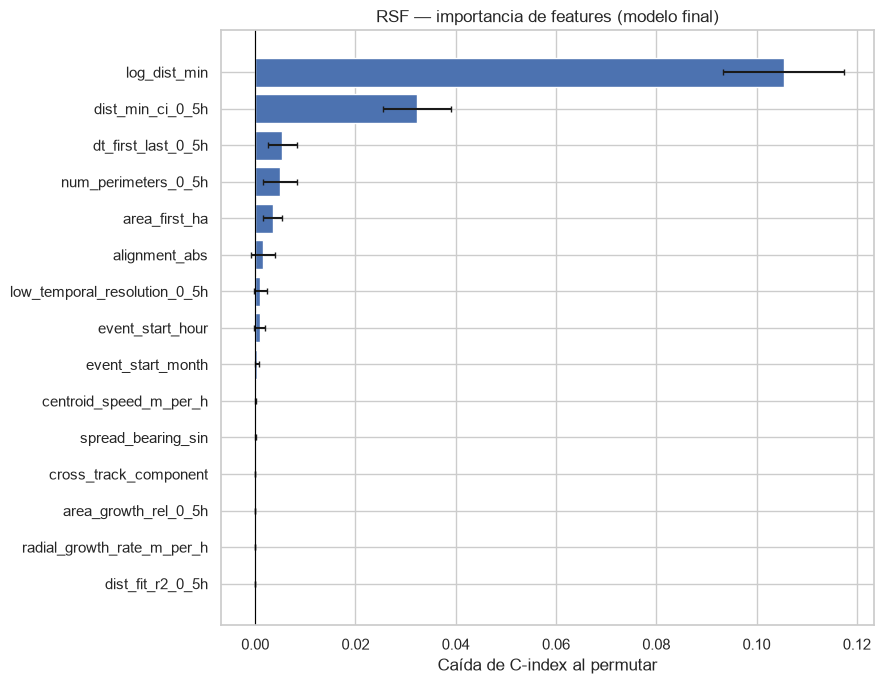

In [5]:
perm = permutation_importance(
    rsf, df_train[RSF_FEATURES].astype(float).values, y, n_repeats=15, random_state=42, n_jobs=-1,
    scoring=lambda est, X, yy: concordance_index_censored(
        yy["event"], yy["time_to_hit_hours"], est.predict(X))[0])
imp = pd.DataFrame({"feature": RSF_FEATURES, "imp": perm.importances_mean,
                    "std": perm.importances_std}).sort_values("imp", ascending=False)
print(imp.head(8).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
top = imp.head(15)[::-1]
ax.barh(top["feature"], top["imp"], xerr=top["std"], color=C0, edgecolor="white", capsize=2)
ax.axvline(0, color="black", lw=0.8)
ax.set(title="RSF — importancia de features (modelo final)", xlabel="Caída de C-index al permutar")
plt.tight_layout()
plt.savefig(FIG_DIR / "14_rsf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

Las dos features de distancia concentran ~72 % de la importancia. El modelo es, en
esencia, un detector de proximidad refinado por el resto de señales.

## 3.5 Curvas de supervivencia por nivel de riesgo

Agrupamos los incendios en cuartiles de riesgo predicho y promediamos sus curvas S(t).
La separación entre cuartiles muestra que el modelo discrimina bien.

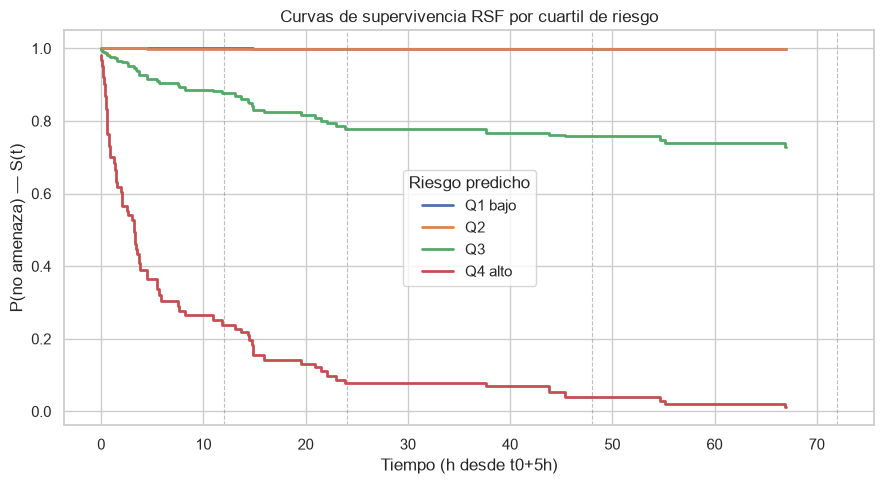

In [6]:
risk = rsf.predict(df_train[RSF_FEATURES].astype(float).values)
quart = pd.qcut(risk, 4, labels=["Q1 bajo", "Q2", "Q3", "Q4 alto"])
sf = rsf.predict_survival_function(df_train[RSF_FEATURES].astype(float).values)

fig, ax = plt.subplots(figsize=(9, 5))
for q, color in zip(["Q1 bajo", "Q2", "Q3", "Q4 alto"], [C0, C1, C2, C3]):
    idx = np.where(quart == q)[0]
    times = sf[idx[0]].x
    ax.step(times, np.mean([sf[i](times) for i in idx], axis=0), where="post", lw=2, label=q, color=color)
for h in HORIZONS:
    ax.axvline(h, color="gray", lw=0.8, ls="--", alpha=0.5)
ax.set(xlabel="Tiempo (h desde t0+5h)", ylabel="P(no amenaza) — S(t)",
       title="Curvas de supervivencia RSF por cuartil de riesgo")
ax.legend(title="Riesgo predicho")
plt.tight_layout()
plt.savefig(FIG_DIR / "15_rsf_survival_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.6 Calibración

Como la submission puntúa probabilidades, verificamos calibración con predicciones
**out-of-fold** (CV): agrupamos por decil de probabilidad predicha y comparamos contra
la tasa observada. Cerca de la diagonal = bien calibrado.

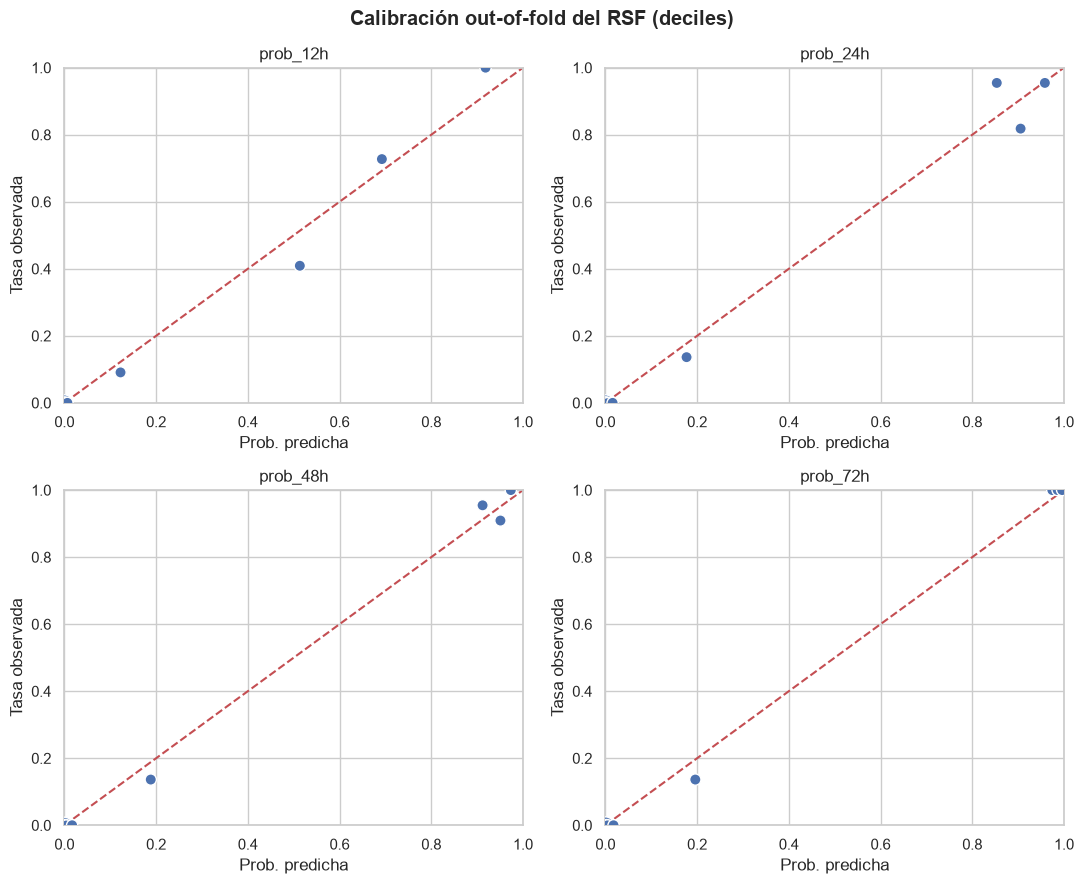

In [7]:
oof = {col: np.zeros(len(df_train)) for col in HORIZON_COLS}
for tr, va in cv.split(df_train, strat):
    m = RandomSurvivalForest(**best, n_jobs=-1, random_state=42)
    m.fit(df_train[RSF_FEATURES].astype(float).values[tr], y[tr])
    sf_va = stepfn_to_matrix(
        m.predict_survival_function(df_train[RSF_FEATURES].astype(float).values[va]), HORIZONS)
    for j, col in enumerate(HORIZON_COLS):
        oof[col][va] = 1 - sf_va[:, j]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (col, h) in zip(axes.flat, zip(HORIZON_COLS, HORIZONS)):
    pred = oof[col]
    obs = ((df_train["event"] == 1) & (df_train["time_to_hit_hours"] <= h)).astype(float)
    g = pd.DataFrame({"pred": pred, "obs": obs, "d": pd.qcut(pred, 10, duplicates="drop")})
    grp = g.groupby("d", observed=True).agg(p=("pred", "mean"), o=("obs", "mean"), n=("obs", "count"))
    ax.scatter(grp["p"], grp["o"], s=grp["n"] * 3, color=C0, edgecolors="white", zorder=3)
    ax.plot([0, 1], [0, 1], "r--", lw=1.5)
    ax.set(title=col, xlabel="Prob. predicha", ylabel="Tasa observada", xlim=(0, 1), ylim=(0, 1))
plt.suptitle("Calibración out-of-fold del RSF (deciles)", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "16_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.7 Predicción en test y submission

`prob_h = 1 - S(h)`. Verificamos el formato exacto contra `sample_submission.csv`.

In [8]:
sf_te = rsf.predict_survival_function(df_test[RSF_FEATURES].astype(float).values)
S_te = stepfn_to_matrix(sf_te, HORIZONS)

submission = df_test[["event_id"]].copy()
for j, col in enumerate(HORIZON_COLS):
    submission[col] = np.clip(1 - S_te[:, j], 0, 1)

sample = pd.read_csv(Path("data") / "sample_submission.csv") if Path("data/sample_submission.csv").exists() \
    else pd.read_csv(Path("../data") / "sample_submission.csv")
assert list(submission.columns) == list(sample.columns), "columnas no coinciden"
assert submission["event_id"].tolist() == sample["event_id"].tolist(), "event_id no alineado"

out = SUB_DIR / "submission_rsf.csv"
submission.to_csv(out, index=False)
print(f"Submission guardada: {out}  {submission.shape}")
print("\nProbabilidad media de amenaza por horizonte:")
for col in HORIZON_COLS:
    print(f"  {col}: {submission[col].mean():.3f}")
print(submission.head().to_string(index=False))

Submission guardada: submissions\submission_rsf.csv  (95, 5)

Probabilidad media de amenaza por horizonte:
  prob_12h: 0.185
  prob_24h: 0.264
  prob_48h: 0.280
  prob_72h: 0.298
 event_id  prob_12h  prob_24h  prob_48h  prob_72h
 10662602  0.000000  0.001605  0.002125  0.002385
 13353600  0.594218  0.916947  0.968976  0.997600
 13942327  0.000000  0.002022  0.002541  0.002801
 16112781  0.565533  0.892269  0.945703  0.998222
 17132808  0.116586  0.116586  0.116586  0.116586


## 3.8 Distribución de las predicciones

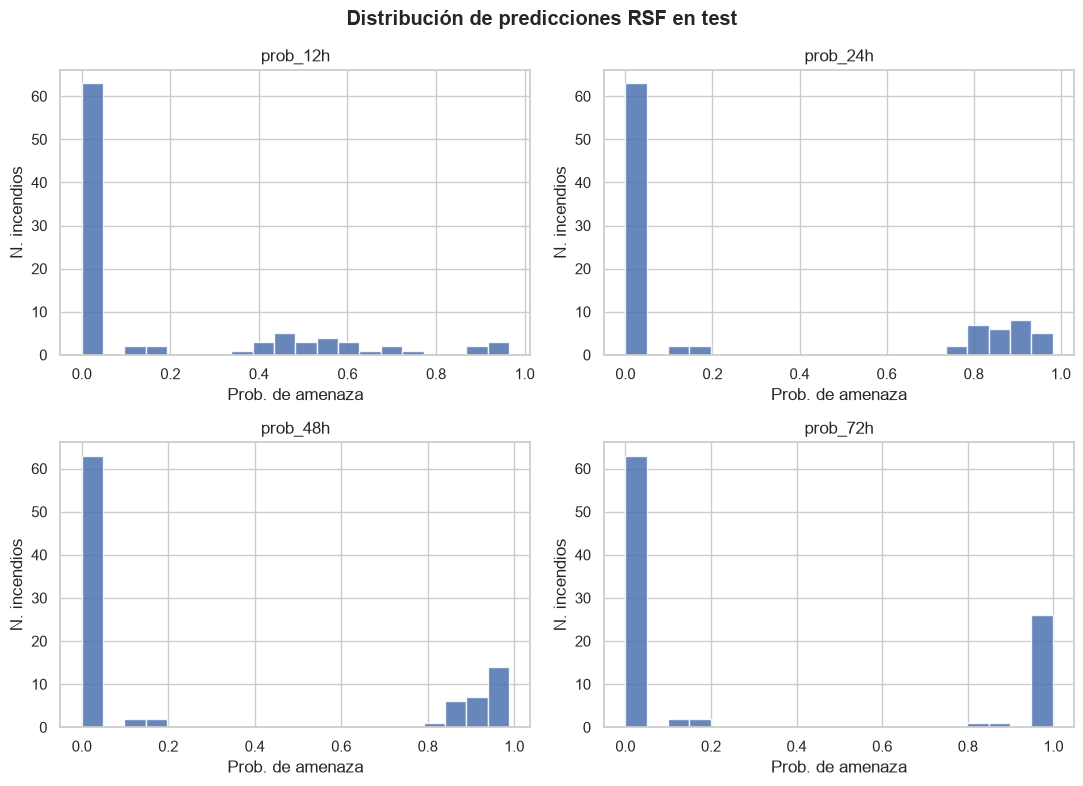

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flat, HORIZON_COLS):
    ax.hist(submission[col], bins=20, color=C0, edgecolor="white", alpha=0.85)
    ax.set(title=col, xlabel="Prob. de amenaza", ylabel="N. incendios")
plt.suptitle("Distribución de predicciones RSF en test", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "17_prediction_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Resumen

- Hiperparámetros: `n_estimators=300, min_samples_leaf=10, max_features=0.5`.
- **C-index CV ≈ 0.948** con 24 features; equivalente a usar las 33.
- El riesgo lo domina la distancia inicial; el modelo está bien calibrado.
- Submission en `submissions/submission_rsf.csv`.

La comparación formal contra Cox y KM, y la validación de honestidad, están en
`validation.ipynb`.